World Cup Hocky 2026 prediction including group stage, possible second round, semi-finals and final

In [1]:
import numpy as np
import pandas as pd

from itertools import combinations
from collections import Counter, defaultdict

import random

Teams and their ratings (Data source: https://www.fih.hockey/outdoor-hockey-rankings)

In [2]:
teams = ["Netherlands","Argentina","New Zealand","Japan","Belgium","Germany","France","Malaysia","Australia","Spain","Ireland","South Africa","England","India","Pakistan","Wales"]

ratings = {"Netherlands":3613,"Belgium":3838,"Germany":3406,"Australia":3495,"England":3599,"India":3234,"Argentina":3265,"Spain":3297,"France":2796,"Ireland":2795,
    "New Zealand":2737,"Pakistan":2550,"Malaysia":2452,"Japan":2412,"South Africa":2542,"Wales":2429}

Pools

In [3]:
POOLS = {
    "A": ["Netherlands", "Argentina", "New Zealand", "Japan"],

    "B": ["Belgium", "Germany", "France", "Malaysia"],

    "C": ["Australia", "Spain", "Ireland", "South Africa"],

    "D": ["England", "India", "Pakistan", "Wales"]}

Winning probabilities of the teams

In [4]:
def win_probability(team1, team2):
    r1 = ratings[team1]
    r2 = ratings[team2]
    return 1 / (1 + 10 ** ((r2 - r1) / 400))

Expected goals of each match

In [5]:
def expected_goals(team1, team2):
    p = win_probability(team1, team2)
    xg1 = 1.5 + 3*p
    xg2 = 1.5 + 3*(1-p)
    return xg1, xg2

Simulation of the matches

In [6]:
def simulate_match(team1, team2):
    xg1, xg2 = expected_goals(team1, team2)
    goals1 = np.random.poisson(xg1)
    goals2 = np.random.poisson(xg2)
    return goals1, goals2

Penalty shootout simulator

In [7]:
def penalty_shootout(team1, team2):
    p = win_probability(team1, team2)
    if random.random() < p:
        return team1
    else:
        return team2

Group and second round tables

In [8]:
def create_table(pool):
    return {
        team:{  "Pts":0, "GF":0, "GA":0, "GD":0, "W":0, "D":0, "L":0 }
        for team in pool
    }

Updating the tables

In [9]:
def update_table(table, team1, team2, g1, g2):
    table[team1]["GF"] += g1
    table[team1]["GA"] += g2
    table[team2]["GF"] += g2
    table[team2]["GA"] += g1
    table[team1]["GD"] = table[team1]["GF"] - table[team1]["GA"]
    table[team2]["GD"] = table[team2]["GF"] - table[team2]["GA"]

    if g1 > g2:

        table[team1]["Pts"] += 3
        table[team1]["W"] += 1
        table[team2]["L"] += 1

    elif g2 > g1:

        table[team2]["Pts"] += 3
        table[team2]["W"] += 1
        table[team1]["L"] += 1

    else:

        table[team1]["Pts"] += 1
        table[team2]["Pts"] += 1

        table[team1]["D"] += 1
        table[team2]["D"] += 1

Ranking of the teams

In [11]:
def rank_teams(table):
    return sorted(
        table.keys(),
        key=lambda x: ( table[x]["Pts"], table[x]["GD"], table[x]["GF"]),
        reverse=True
    )

Pool matches simulation

In [12]:
def simulate_pool(pool_teams):
    table = create_table(pool_teams)
    results = {}
    matches = list(combinations(pool_teams, 2))
    for team1, team2 in matches:
        g1, g2 = simulate_match(team1, team2)
        update_table(table,team1,team2,g1,g2)
        results[(team1, team2)] = (g1, g2)

    ranking = rank_teams(table)
    return table, results, ranking

First round simulation

In [14]:
def first_round():
    qualified = {}
    pool_data = {}
    for pool_name, teams in POOLS.items():
        table, results, ranking = simulate_pool(teams)
        qualified[pool_name] = ranking[:2]
        pool_data[pool_name] = { "table":table, "results":results, "ranking":ranking}

    return qualified, pool_data

Second round simulation

In [15]:
def build_second_round_pools(qualified):
    pool_E = ( qualified["A"] + qualified["D"])
    pool_F = ( qualified["C"] + qualified["B"])
    return pool_E, pool_F

Second round tables

In [16]:
def create_second_round_table(teams):
    return {team:{"Pts":0,"GF":0,"GA":0,"GD":0}
        for team in teams}

Carry forwarding the points(as per the rule)

In [17]:
def carry_forward_E(pool_E,qualified,pool_data):
    table = create_second_round_table(pool_E)
    carried_matches = set()
    A1,A2 = qualified["A"]
    B1,B2 = qualified["B"]
    qualifying_pairs = [(A1,A2),(B1,B2) ]

    for t1,t2 in qualifying_pairs:
        result_found = False
        for match,result in pool_data["A"]["results"].items():
            if set(match) == set((t1,t2)):
                g1,g2 = result
                team1,team2 = match
                result_found = True
                break

        if not result_found:
            for match,result in pool_data["B"]["results"].items():
                if set(match) == set((t1,t2)):
                    g1,g2 = result
                    team1,team2 = match
                    break

        carried_matches.add(tuple(sorted([team1,team2])))

        table[team1]["GF"] += g1
        table[team1]["GA"] += g2
        table[team2]["GF"] += g2
        table[team2]["GA"] += g1

        table[team1]["GD"] = ( table[team1]["GF"] - table[team1]["GA"] )
        table[team2]["GD"] = ( table[team2]["GF"] - table[team2]["GA"])

        if g1 > g2:

            table[team1]["Pts"] += 3

        elif g2 > g1:

            table[team2]["Pts"] += 3

        else:

            table[team1]["Pts"] += 1
            table[team2]["Pts"] += 1

    return table, carried_matches

In [18]:
def carry_forward_pool(
    teams,
    qualified1,
    qualified2,
    results1,
    results2
):

    table = create_second_round_table(teams)

    carried = set()

    pairs = [
        tuple(qualified1),
        tuple(qualified2)
    ]

    result_sources = [
        results1,
        results2
    ]

    for pair,source in zip(
        pairs,
        result_sources
    ):

        t1,t2 = pair

        for match,result in source.items():

            if set(match) == set(pair):

                g1,g2 = result

                team1,team2 = match

                carried.add(
                    tuple(sorted(match))
                )

                table[team1]["GF"] += g1
                table[team1]["GA"] += g2

                table[team2]["GF"] += g2
                table[team2]["GA"] += g1

                table[team1]["GD"] = (
                    table[team1]["GF"]
                    - table[team1]["GA"]
                )

                table[team2]["GD"] = (
                    table[team2]["GF"]
                    - table[team2]["GA"]
                )

                if g1 > g2:

                    table[team1]["Pts"] += 3

                elif g2 > g1:

                    table[team2]["Pts"] += 3

                else:

                    table[team1]["Pts"] += 1
                    table[team2]["Pts"] += 1

    return table, carried

Simulation of the second round

In [20]:
def simulate_second_round_pool( teams, table, carried_matches):
    all_matches = list( combinations(teams,2))

    for team1,team2 in all_matches:
        key = tuple(sorted([team1,team2]))

        if key in carried_matches:
            continue

        g1,g2 = simulate_match(team1,team2)

        table[team1]["GF"] += g1
        table[team1]["GA"] += g2

        table[team2]["GF"] += g2
        table[team2]["GA"] += g1

        table[team1]["GD"] = ( table[team1]["GF"] - table[team1]["GA"])
        table[team2]["GD"] = (table[team2]["GF"]- table[team2]["GA"])

        if g1 > g2:
            table[team1]["Pts"] += 3
        elif g2 > g1:
            table[team2]["Pts"] += 3

        else:
            table[team1]["Pts"] += 1
            table[team2]["Pts"] += 1

    return table

Second round rankings

In [21]:
def rank_second_round(table):
    return sorted( table.keys(),key=lambda x: (table[x]["Pts"],table[x]["GD"],table[x]["GF"]),reverse=True )

Second round

In [22]:
def second_round(qualified,pool_data):
    pool_E, pool_F = build_second_round_pools(qualified)

    table_E, carried_E = carry_forward_pool(pool_E, qualified["A"], qualified["D"], pool_data["A"]["results"], pool_data["D"]["results"])
    table_F, carried_F = carry_forward_pool( pool_F, qualified["C"], qualified["B"],  pool_data["C"]["results"],pool_data["B"]["results"])
    table_E = simulate_second_round_pool(pool_E,table_E,carried_E)
    table_F = simulate_second_round_pool( pool_F, table_F, carried_F)

    ranking_E = rank_second_round(table_E)
    ranking_F = rank_second_round(table_F)
    return (ranking_E,ranking_F,table_E,table_F)



Displaying second round tables

In [23]:
def display_second_round_tables(table_E, table_F):
    df_E = pd.DataFrame(table_E).T
    df_E = df_E.sort_values( ["Pts","GD","GF"], ascending=False)

    print("\nPOOL E")
    print(df_E)

    df_F = pd.DataFrame(table_F).T

    df_F = df_F.sort_values(["Pts","GD","GF"], ascending=False)
    print("\nPOOL F")
    print(df_F)

In [26]:
qualified, pool_data = first_round()
ranking_E, ranking_F, table_E, table_F = second_round( qualified, pool_data)
display_second_round_tables(table_E, table_F)



POOL E
             Pts  GF  GA  GD
England        9  14   7   7
Netherlands    3  11  11   0
Argentina      3  10  10   0
India          3   6  13  -7

POOL F
           Pts  GF  GA  GD
Australia    6  13   4   9
Belgium      6  10   6   4
France       4   4   7  -3
Spain        1   4  14 -10


Knockout matches

In [27]:
def knockout_match(team1, team2):
    g1, g2 = simulate_match(team1, team2)
    if g1 > g2:
        return team1
    elif g2 > g1:
        return team2

    else:
        winner = penalty_shootout(team1, team2)
        return winner

Semi-final matches

In [28]:
def semifinals(ranking_E, ranking_F):
    E1 = ranking_E[0]
    E2 = ranking_E[1]
    F1 = ranking_F[0]
    F2 = ranking_F[1]
    g1, g2 = simulate_match(E1, F2)
    if g1 == g2:
        sf1_winner = penalty_shootout(E1, F2)
    else:
        sf1_winner = E1 if g1 > g2 else F2

    g3, g4 = simulate_match(F1, E2)

    if g3 == g4:
        sf2_winner = penalty_shootout(F1, E2)
    else:
        sf2_winner = F1 if g3 > g4 else E2

    semi_results = [(E1, F2, g1, g2, sf1_winner),(F1, E2, g3, g4, sf2_winner)]
    finalists = [sf1_winner, sf2_winner]
    return finalists, semi_results



Displaying semi-finals

In [29]:
def display_semifinals(semi_results):
    print("\nSEMIFINALS")
    rows = []
    for t1,t2,g1,g2,winner in semi_results:
        rows.append([ t1, g1, g2, t2, winner])

    df = pd.DataFrame(rows, columns=["Team 1","Goals 1","Goals 2","Team 2","Winner"])
    print(df)

Final match simulation

In [30]:
def final_match(finalists):
    t1,t2 = finalists
    g1,g2 = simulate_match(t1,t2)
    if g1 == g2:
        champion = penalty_shootout(t1, t2)

    else:
        champion = (t1 if g1>g2 else t2)

    final_result = ( t1, t2, g1, g2, champion)
    return champion, final_result

Displaying final match

In [31]:
def display_final(final_result):
    t1,t2,g1,g2,champion = final_result
    print("\nFINAL")
    df = pd.DataFrame({ "Team 1":[t1],"Goals 1":[g1],"Goals 2":[g2],"Team 2":[t2],"Champion":[champion]})
    print(df)

Simulating tournament stats

In [32]:
def simulate_tournament_stats():
    qualified, pool_data = first_round()
    ranking_E, ranking_F, table_E, table_F = second_round( qualified, pool_data)
    finalists, semi_results = semifinals(ranking_E,ranking_F)
    champion, final_result = final_match(finalists)

    return ( champion, table_E,table_F,semi_results,final_result,finalists,ranking_E,ranking_F,
        pool_data["A"]["ranking"],pool_data["B"]["ranking"],pool_data["C"]["ranking"],pool_data["D"]["ranking"])

Counter and simulations (one lakh)

In [33]:
from collections import Counter
N_SIMULATIONS = 100000
champions = Counter()
second_round_count = Counter()
semifinal_count = Counter()
finalists_count = Counter()
semi_pairings = Counter()
final_pairings = Counter()
poolE_rankings = Counter()
poolF_rankings = Counter()
groupA_rankings = Counter()
groupB_rankings = Counter()
groupC_rankings = Counter()
groupD_rankings = Counter()

last_table_E = None
last_table_F = None
last_semi_results = None
last_final_result = None

for _ in range(N_SIMULATIONS):
    (winner,table_E,table_F,semi_results,final_result,finalists,ranking_E,ranking_F, ranking_A,ranking_B,ranking_C,ranking_D) = simulate_tournament_stats()

    champions[winner] += 1
    groupA_rankings[tuple(ranking_A)] += 1
    groupB_rankings[tuple(ranking_B)] += 1
    groupC_rankings[tuple(ranking_C)] += 1
    groupD_rankings[tuple(ranking_D)] += 1


    for team in ranking_E:
       second_round_count[team] += 1
    for team in ranking_F:
       second_round_count[team] += 1

    for match_info in semi_results:
        semifinal_count[match_info[0]] += 1
        semifinal_count[match_info[1]] += 1


    for team in finalists: finalists_count[team] += 1

    poolE_rankings[tuple(ranking_E)] += 1
    poolF_rankings[tuple(ranking_F)] += 1

    last_table_E = table_E
    last_table_F = table_F
    last_semi_results = semi_results
    last_final_result = final_result

    semi_pairings[ ( semi_results[0][0],semi_results[0][1],semi_results[1][0],semi_results[1][1])] += 1

    final_pairings[tuple(sorted(finalists))] += 1

Champion probabilities

In [34]:
championship_probabilities = {}

for team in teams:
    championship_probabilities[team] = (champions[team] / N_SIMULATIONS ) * 100

In [35]:
results_df = pd.DataFrame({"Team": championship_probabilities.keys(),"Champion Probability (%)": championship_probabilities.values()})
results_df = results_df.sort_values( by="Champion Probability (%)", ascending=False)
results_df.reset_index( drop=True,inplace=True)
results_df

,Team,Champion Probability (%)
0,Belgium,62.349
1,Netherlands,15.943
2,England,14.109
3,Australia,4.854
4,Germany,1.558
5,Spain,0.480
6,Argentina,0.390
7,India,0.295
8,New Zealand,0.007
9,France,0.006


In [36]:
print( "\n2026 Men's Hockey World Cup winner prediction\n")

for idx,row in results_df.iterrows():
    print( f"{idx+1:2d}. "  f"{row['Team']:15s} "f"{row['Champion Probability (%)']:.2f}%")


2026 Men's Hockey World Cup winner prediction

 1. Belgium         62.35%
 2. Netherlands     15.94%
 3. England         14.11%
 4. Australia       4.85%
 5. Germany         1.56%
 6. Spain           0.48%
 7. Argentina       0.39%
 8. India           0.29%
 9. New Zealand     0.01%
10. France          0.01%
11. Ireland         0.00%
12. Japan           0.00%
13. Wales           0.00%
14. Pakistan        0.00%
15. Malaysia        0.00%
16. South Africa    0.00%


In [37]:
results_df.to_csv( "hockey_world_cup_predictions.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


Most likely Pool results (A,B,C,D) and a sample tournament

In [39]:
print("\n")
print("="*70)
print("SAMPLE TOURNAMENT FROM SIMULATION")
print("="*70)

display_second_round_tables(last_table_E, last_table_F)

print("\nSEMIFINALS")
display_semifinals( last_semi_results)

print("\nFINAL")
display_final(last_final_result)



SAMPLE TOURNAMENT FROM SIMULATION

POOL E
             Pts  GF  GA  GD
Netherlands    9  13   2  11
India          6   8  10  -2
England        3   4   7  -3
Argentina      0   4  10  -6

POOL F
           Pts  GF  GA  GD
Belgium      9  17   6  11
Australia    6   9   4   5
Spain        1   6  13  -7
Germany      1   3  12  -9

SEMIFINALS

SEMIFINALS
        Team 1  Goals 1  Goals 2     Team 2     Winner
0  Netherlands        2        4  Australia  Australia
1      Belgium        3        3      India    Belgium

FINAL

FINAL
      Team 1  Goals 1  Goals 2   Team 2 Champion
0  Australia        1        4  Belgium  Belgium


In [40]:
def display_most_likely_group(counter, group_name):
    ranking, count = counter.most_common(1)[0]
    df = pd.DataFrame({ "Position":[1,2,3,4], "Team":list(ranking)})

    print("\n" + "="*60)
    print(f"MOST LIKELY GROUP {group_name}")
    print("="*60)

    display(df)

    print(
        f"Occurred in "
        f"{100*count/N_SIMULATIONS:.2f}% "
        f"of simulations"
    )

In [41]:
display_most_likely_group(groupA_rankings, "A")
display_most_likely_group( groupB_rankings, "B")
display_most_likely_group(groupC_rankings, "C")
display_most_likely_group( groupD_rankings, "D")


MOST LIKELY GROUP A


,Position,Team
0,1,Netherlands
1,2,Argentina
2,3,New Zealand
3,4,Japan


Occurred in 51.16% of simulations

MOST LIKELY GROUP B


,Position,Team
0,1,Belgium
1,2,Germany
2,3,France
3,4,Malaysia


Occurred in 53.41% of simulations

MOST LIKELY GROUP C


,Position,Team
0,1,Australia
1,2,Spain
2,3,Ireland
3,4,South Africa


Occurred in 43.74% of simulations

MOST LIKELY GROUP D


,Position,Team
0,1,England
1,2,India
2,3,Pakistan
3,4,Wales


Occurred in 42.91% of simulations


Most likely Pool E and Pool F

In [42]:
print("="*70)
print("MOST LIKELY POOL E TABLE")
print("="*70)

most_likely_E, count_E = poolE_rankings.most_common(1)[0]

dfE = pd.DataFrame({"Position": [1,2,3,4], "Team": list(most_likely_E)})
display(dfE)
print(
    f"Occurred in {100*count_E/N_SIMULATIONS:.2f}% "
    f"of simulations"
)

MOST LIKELY POOL E TABLE


,Position,Team
0,1,Netherlands
1,2,England
2,3,Argentina
3,4,India


Occurred in 13.54% of simulations


In [43]:
print("="*70)
print("MOST LIKELY POOL F TABLE")
print("="*70)

most_likely_F, count_F = poolF_rankings.most_common(1)[0]

dfF = pd.DataFrame({ "Position": [1,2,3,4], "Team": list(most_likely_F)})

display(dfF)

print(
    f"Occurred in {100*count_F/N_SIMULATIONS:.2f}% "
    f"of simulations"
)

MOST LIKELY POOL F TABLE


,Position,Team
0,1,Belgium
1,2,Australia
2,3,Germany
3,4,Spain


Occurred in 17.78% of simulations


In [44]:
print("\nMOST LIKELY SEMIFINAL SETUPS")
print("="*70)

for pairing, count in semi_pairings.most_common(5):

    prob = 100 * count / N_SIMULATIONS

    print(
        pairing,
        f" : {prob:.2f}%"
    )

print("\nMOST LIKELY FINALS")
print("="*70)

for pairing, count in final_pairings.most_common(5):

    prob = 100 * count / N_SIMULATIONS

    print(
        pairing,
        f" : {prob:.2f}%"
    )


MOST LIKELY SEMIFINAL SETUPS
('Netherlands', 'Australia', 'Belgium', 'England')  : 13.76%
('England', 'Australia', 'Belgium', 'Netherlands')  : 12.42%
('Netherlands', 'Germany', 'Belgium', 'England')  : 7.67%
('England', 'Germany', 'Belgium', 'Netherlands')  : 7.14%
('Netherlands', 'Spain', 'Belgium', 'England')  : 4.00%

MOST LIKELY FINALS
('Belgium', 'Netherlands')  : 25.81%
('Belgium', 'England')  : 23.25%
('Australia', 'Belgium')  : 15.93%
('England', 'Netherlands')  : 12.11%
('Belgium', 'Germany')  : 6.12%


In [45]:
records = []

for team in teams:

    records.append({

        "Team": team,

        "Second Round pp":
            100 * second_round_count[team] / N_SIMULATIONS,

        "Semi Final pp":
            100 * semifinal_count[team] / N_SIMULATIONS,

        "Final pp":
            100 * finalists_count[team] / N_SIMULATIONS,

        "Champion %":
            100 * champions[team] / N_SIMULATIONS
    })

results_df = pd.DataFrame(records)

results_df = results_df.sort_values(
    "Champion %",
    ascending=False
)

results_df

,Team,Second Round pp,Semi Final pp,Final pp,Champion %
4,Belgium,96.802,91.331,75.467,62.349
0,Netherlands,96.285,83.056,43.536,15.943
12,England,96.572,81.867,40.514,14.109
8,Australia,94.818,56.744,22.461,4.854
5,Germany,84.802,31.904,9.110,1.558
9,Spain,85.890,17.224,3.485,0.480
1,Argentina,84.568,17.531,2.792,0.390
13,India,86.204,15.095,2.216,0.295
2,New Zealand,15.365,1.195,0.108,0.007
6,France,14.784,1.116,0.105,0.006


Plot of all teams

In [46]:
import matplotlib.pyplot as plt


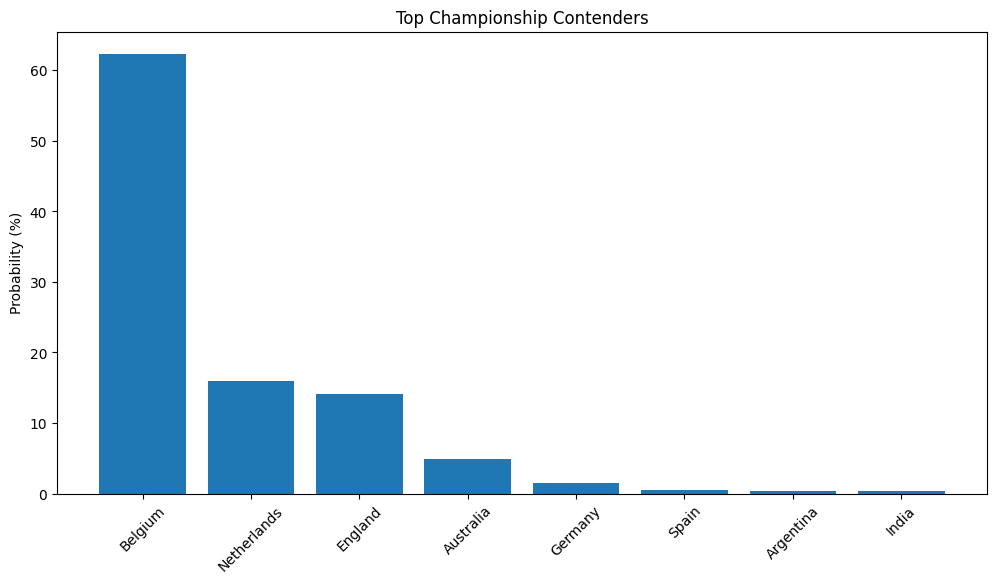

In [47]:
top8 = results_df.head(8)

plt.figure(figsize=(12,6))

plt.bar(
    top8["Team"],
    top8["Champion %"]
)

plt.xticks(rotation=45)

plt.ylabel("Probability (%)")

plt.title(
    "Top Championship Contenders"
)

plt.show()